# EA Sports FC 24 - Player Market Value Analysis

## [1] Dataset Summary

**Dataset Overview**
The dataset selected for this analysis contains comprehensive player statistics, attributes, and market valuations from EA Sports FC 24. It provides a highly granular view of professional football players globally. 

**Variables Description**
The features within the dataset can be categorized into four main pillars:
* **Demographic & Biographical:** Age, Nationality, Club, Preferred Foot.
* **Physical Attributes:** Height, Weight, Body Type.
* **Performance Metrics (Skill Ratings):** Granular stats graded out of 99, including Pace, Shooting, Passing, Dribbling, Defending, and Physicality.
* **Economic Variables:** Overall Rating, Potential Rating, Wage, and Value in EUR.

**Target Variable**
The primary target variable for this analysis is **`value_eur` (Player Market Value)**. Understanding what specific attributes and demographic factors drive a player's financial valuation is crucial for identifying undervalued talent.

---

## [2] Data Exploration Plan

**Vision for Analysis**
The overarching vision of this analysis is to decode the fundamental drivers of a player's market value. By exploring the relationships between specific in-game physical/technical attributes and economic valuation, we aim to uncover hidden biases in how players are priced.

**Key Questions and Roadmap**
1. **The Age Curve:** How does a player's age correlate with their market value and overall rating? 
2. **Attribute Premiums:** Are certain attributes disproportionately valued by the market? (e.g., Pace vs. Defending).
3. **The Potential Gap:** How does the gap between a player's current 'Overall' rating and their 'Potential' rating affect their immediate market value?

In [3]:
import pandas as pd


df = pd.read_csv('male_players.csv', low_memory=False)


df_fc24 = df[df['fifa_version'] == 24.0].copy()


print(f"FC 24 Number of Players and Columns: {df_fc24.shape}")


df_fc24.head()

FC 24 Number of Players and Columns: (18350, 109)


,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,...,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,...,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,...,63+3,63+3,63+3,64+3,59+3,49+3,49+3,49+3,59+3,19+3
4,165153,/player/165153/karim-benzema/240002,24.0,2.0,2023-09-22,K. Benzema,Karim Benzema,"CF, ST",90,90,...,64+3,64+3,64+3,64+3,60+3,55+3,55+3,55+3,60+3,18+3


## [3] Data Cleaning & Feature Engineering

Before diving into the visual analysis, the dataset requires structural cleaning and the engineering of new features to make our analysis more robust.

**Handling Missing Values**
Our primary target variable is `value_eur`. Any player record missing this financial valuation cannot contribute to our core analysis. Therefore, we will identify and completely drop rows where the market value is missing (NaN). 

**Feature Engineering: Potential Growth**
In the context of football and EA Sports FC, a player's current rating only tells half the story. The gap between their current ability and their maximum potential heavily dictates their market value (especially for younger players). To capture this, we will engineer a new feature called `potential_growth`, calculated as the difference between `potential` and `overall`.

In [ ]:

print("Number of missing value_eur entries before deletion:", df_fc24['value_eur'].isnull().sum())


df_fc24 = df_fc24.dropna(subset=['value_eur'])


print("Number of players remaining after cleanup:", df_fc24.shape[0])


Number of missing value_eur entries before deletion: 100
Number of players remaining after cleanup: 18250


In [7]:
df_fc24['potential_growth']=df_fc24['potential']-df_fc24['overall']
df_fc24[['short_name','overall','potential','potential_growth']]

C:\Users\Fukan (MONSTER)\AppData\Local\Temp\ipykernel_17536\4247290077.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fc24['potential_growth']=df_fc24['potential']-df_fc24['overall']


,short_name,overall,potential,potential_growth
0,K. Mbappé,91,94,3
1,E. Haaland,91,94,3
2,K. De Bruyne,91,91,0
3,L. Messi,90,90,0
4,K. Benzema,90,90,0
...,...,...,...,...
18345,S. Telem,47,57,10
18346,Jin Liangkuan,47,55,8
18347,M. Mewlan,47,55,8
18348,Yin Jie,47,54,7


## [4] Exploratory Data Analysis (EDA)

With a clean dataset and newly engineered features, we can begin uncovering the fundamental distributions within our data. 

**1. The Age Distribution of Professional Footballers**
Age is arguably the most critical demographic factor in sports. Before analyzing how age affects market value, we must first understand the general age distribution of the players in our dataset. We expect to see a normal distribution, likely peaking around the mid-20s, which is traditionally considered the physical peak for athletes.

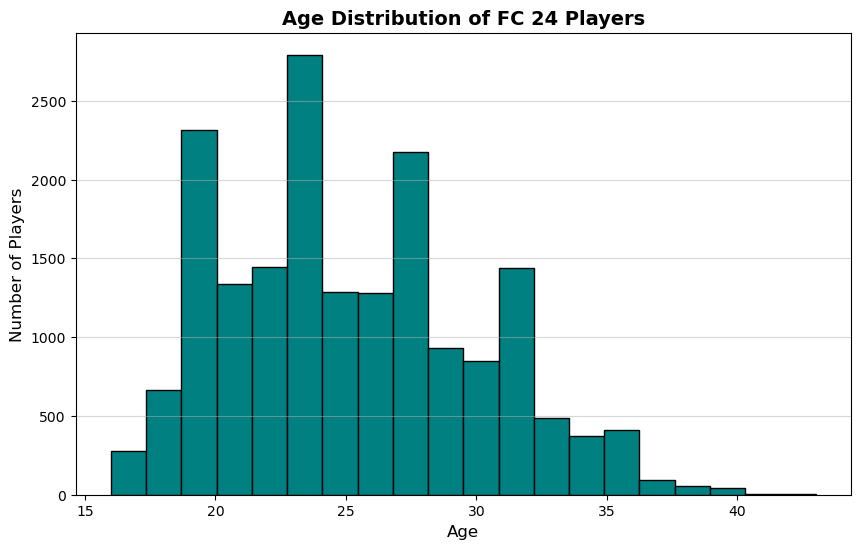

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.hist(df_fc24['age'],bins=20,color='teal',edgecolor='black')

plt.title('Age Distribution of FC 24 Players',fontsize=14,fontweight='bold')
plt.xlabel('Age',fontsize=12)
plt.ylabel('Number of Players',fontsize=12)

plt.grid(axis='y',alpha=0.5)
plt.show()